In [1]:
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import seaborn as sns
import ast
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

df['job_skills'] = df['job_skills'].apply(
    lambda skill_list: ast.literal_eval(skill_list) if isinstance(skill_list, str) else skill_list
)

c:\Users\DELL\anaconda3\envs\data_project\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df_us = df[(df['job_country'] == 'United States')].dropna(subset=['salary_year_avg'])

In [3]:
job_titles = df_us['job_title_short'].value_counts().index[:5].tolist()
job_titles

['Data Scientist',
 'Data Analyst',
 'Data Engineer',
 'Senior Data Scientist',
 'Senior Data Engineer']

In [4]:
df_us_top5 = df_us[df_us['job_title_short'].isin(job_titles)]

In [5]:
job_order = df_us_top5.groupby('job_title_short')['salary_year_avg'].median().sort_values(ascending=False).index

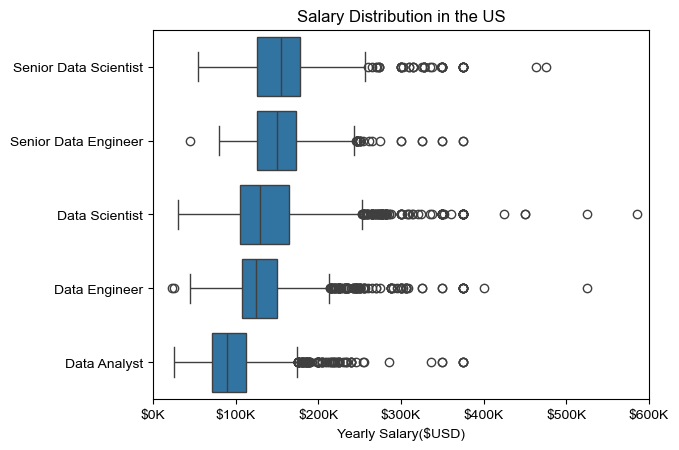

In [6]:
sns.boxplot(data=df_us_top5, x='salary_year_avg', y='job_title_short', order=job_order)
sns.set_theme(style='ticks')

plt.title('Salary Distribution in the US')
plt.xlabel('Yearly Salary($USD)')
plt.ylabel('')
plt.xlim(0, 600000)
ticks_x = plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K')
plt.gca().xaxis.set_major_formatter(ticks_x)
plt.show()

In [7]:
df_DA_us = df[(df['job_country'] == 'United States') & (df['job_title_short'] == 'Data Analyst')].dropna(subset=['salary_year_avg'])

In [11]:
df_exploded = df_DA_us.explode('job_skills')
df_DA_top_pay = df_exploded.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values(by='Median', ascending=False)
df_DA_top_pay = df_DA_top_pay.head(10)


KeyError: 'Median'

In [ ]:
df_exploded = df_DA_us.explode('job_skills')
df_DA_popular_skills = df_exploded.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values(by='median', ascending=False)
df_DA_popular_skills = df_DA_popular_skills.head(10).sort_values(by='median', ascending=False)
df_DA_popular_skills


,count,median
job_skills,,
dplyr,2,196250.0
bitbucket,3,189000.0
gitlab,3,186000.0
solidity,1,179000.0
hugging face,1,175000.0
couchbase,1,160515.0
ansible,1,159640.0
mxnet,2,149000.0
cassandra,6,148250.0


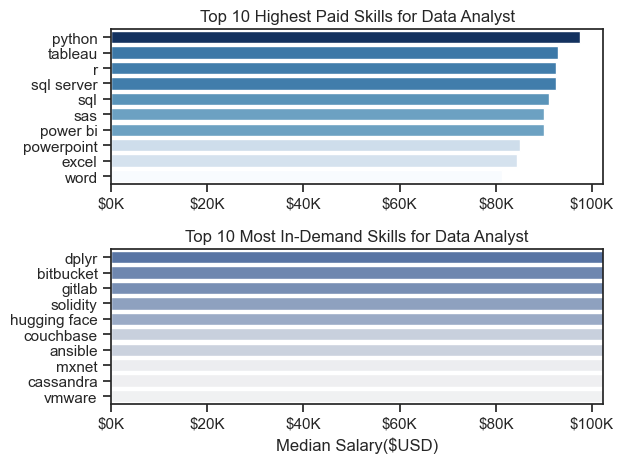

In [ ]:
fig, ax = plt.subplots(2, 1)
sns.set_theme(style='ticks')
# --> Top 10 Highest Paid Skills for Data Analyst
sns.barplot(data=df_DA_top_pay, x='median', y=df_DA_top_pay.index, ax=ax[0], hue='median', palette='Blues')
ax[0].legend().remove()

#df_us_top_pay[::-1].plot(kind='barh', y='median', ax=ax[0], legend=False)
ax[0].set_title('Top 10 Highest Paid Skills for Data Analyst')
ax[0].set_ylabel('')
ax[0].set_xlabel('')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))

# --> Top 10 Most In-Demand Skills for Data Analyst
sns.barplot(data=df_DA_popular_skills, x='median', y=df_DA_popular_skills.index, ax=ax[1], hue='median', palette='light:b')
ax[1].legend().remove()

#df_us_skills_count.plot(kind='barh', y='median', ax=ax[1], legend=False)
#ax[1].invert_yaxis()
ax[1].set_xlim(ax[0].get_xlim())
ax[1].set_title('Top 10 Most In-Demand Skills for Data Analyst')
ax[1].set_ylabel('')
ax[1].set_xlabel('Median Salary($USD)')
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))

fig.tight_layout()
plt.show()